In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [3]:
np.random.seed(42)

In [5]:
n = 100
d = 3
wt = np.array([2.0, -1.0, 0.5])
X = np.random.randn(n, d)
noise = np.random.randn(n) * 0.1
y = X @ wt + noise

In [6]:
y

array([ 1.37263738,  3.10712651,  2.23098307,  1.37670993,  1.53265571,
        0.05711247,  0.45684642, -1.29061204, -1.72047509,  1.18596859,
       -3.08420814, -3.43851091,  1.79584592, -0.177709  , -0.53890598,
       -0.44838815,  2.68051402,  0.18156891,  0.7435268 , -0.47492992,
       -1.31615739, -2.46730335, -1.0485572 , -0.6733781 , -3.04677002,
        1.2858354 ,  2.17706561, -0.94363774, -0.59511712,  1.50673069,
       -1.12674112, -1.08469905,  0.34132247,  0.66815764,  0.13371735,
       -1.00550102, -0.45238863,  1.08622451, -0.66233201, -3.16058483,
        3.11062646, -2.27096269, -1.34045258,  0.52729929, -3.10501581,
        3.74529634,  2.82682028,  4.17333929, -0.95237706, -3.03570717,
       -0.15438411, -0.03820517,  2.74783032,  2.66533734,  3.61765992,
        0.85164525, -0.1836486 , -1.41280874, -0.23502885,  4.44908648,
        1.62498065,  1.69868175,  0.58503129, -2.11480893,  1.82953113,
        1.6912327 ,  1.46069066,  0.56667808, -1.55022845,  2.36

In [16]:
def mseloss(X, y, w):
    return np.mean((X @ w - y) ** 2)

In [9]:
def msegrad(X, y, w):
    n = X.shape[0]
    return (2 / n) * X.T @ (X @ w - y)

In [11]:
msegrad(X, y, wt)

array([0.00575125, 0.00992198, 0.02174907])

In [17]:
w = np.zeros(d)
eta = 0.1
itera = 100
losses = []

for i in range(itera):
    grad = msegrad(X, y, w)
    w = w - eta * grad
    losses.append(mseloss(X, y, w))

print(w)
print(wt)
print(losses)

[ 1.99367926 -1.00693322  0.48981519]
[ 2.  -1.   0.5]
[np.float64(2.891085610198993), np.float64(2.0228387183844205), np.float64(1.4297645394317486), np.float64(1.020007970691563), np.float64(0.7339384386445755), np.float64(0.5323204795089199), np.float64(0.3890032432867913), np.float64(0.2863429592743047), np.float64(0.21229860771999434), np.float64(0.15856496131551456), np.float64(0.11935704030335537), np.float64(0.09060886404577449), np.float64(0.06943902165790018), np.float64(0.05379019589325879), np.float64(0.04218344134044688), np.float64(0.033549022701933724), np.float64(0.027108881255809222), np.float64(0.022294270714495155), np.float64(0.01868757972289176), np.float64(0.01598093696068004), np.float64(0.013946558789691336), np.float64(0.012415377029042688), np.float64(0.011261547639283125), np.float64(0.01039116428425698), np.float64(0.009733997001404242), np.float64(0.009237419605338536), np.float64(0.008861928946282797), np.float64(0.008577827427490576), np.float64(0.0083627

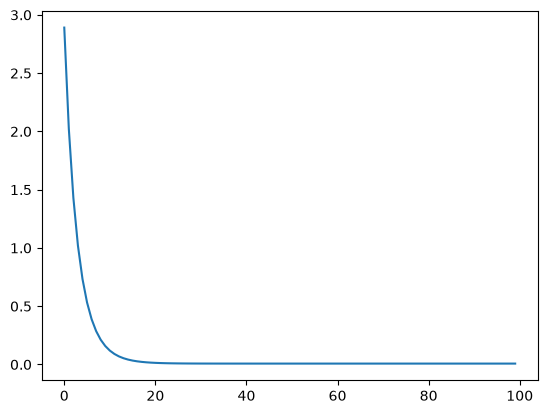

In [18]:
plt.plot(losses)

In [19]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [24]:
random_num = np.random.rand(n)

In [25]:
pt = sigmoid(X @ wt)

In [23]:
pt 

array([0.8108491 , 0.95942354, 0.89625172, 0.78846089, 0.82269963,
       0.51134299, 0.58153549, 0.22592689, 0.14489873, 0.76962374,
       0.04468343, 0.02796635, 0.84726437, 0.4355948 , 0.33861914,
       0.38924462, 0.9316502 , 0.55294962, 0.67064642, 0.38653148,
       0.20984549, 0.07399932, 0.27553174, 0.2926358 , 0.04991792,
       0.80333251, 0.8870799 , 0.26448157, 0.34129488, 0.80905727,
       0.24498948, 0.26993082, 0.58266959, 0.67609291, 0.50905036,
       0.27075502, 0.40857995, 0.75368496, 0.33100897, 0.04293383,
       0.96056427, 0.09151035, 0.2034371 , 0.64060561, 0.04487712,
       0.97638769, 0.95127582, 0.98679785, 0.29306742, 0.04678123,
       0.45376375, 0.45369784, 0.93475069, 0.93591601, 0.97390478,
       0.72149676, 0.45467544, 0.2003765 , 0.43356989, 0.98935338,
       0.82821741, 0.82424949, 0.6447194 , 0.10386677, 0.85327437,
       0.84958563, 0.80818838, 0.63770542, 0.17364721, 0.91974519,
       0.61850706, 0.88053817, 0.17486777, 0.04374937, 0.93987

In [26]:
y = (random_num < pt).astype(float)

In [27]:
pt[:5]

array([0.8108491 , 0.95942354, 0.89625172, 0.78846089, 0.82269963])

In [28]:
y[:5]

array([1., 1., 1., 1., 1.])

In [30]:
np.mean(y)

np.float64(0.61)

In [33]:
def bceloss(X, y, w):
    pt = sigmoid(X @ w)
    pt = np.clip(pt, 1e-7, 1 - 1e-7)
    return -np.mean(y * np.log(pt) + (1-y) * np.log(1 - pt))

In [34]:
w = np.zeros(d)
bceloss(X, y, w)

np.float64(0.6931471805599453)

In [35]:
def bcegrad(X, y, w):
    n = X.shape[0]
    pt = sigmoid(X @ w)
    return (1 / n) * X.T @ (pt - y)

In [46]:
w = np.zeros(d)
eta = 0.1
losses = []
for i in range(100):
    grad = bcegrad(X, y, w)
    w = w - eta * grad
    losses.append(bceloss(X, y, w))

losses

[np.float64(-0.021027794612040407),
 np.float64(-0.6953366065660189),
 np.float64(-1.3363023923134079),
 np.float64(-1.9509927391031743),
 np.float64(-2.5455391932796605),
 np.float64(-3.124738171191587),
 np.float64(-3.692179238452929),
 np.float64(-4.2505115582752815),
 np.float64(-4.801692879300951),
 np.float64(-5.347182788385228),
 np.float64(-5.8880828081200445),
 np.float64(-6.425235451009404),
 np.float64(-6.959293870274024),
 np.float64(-7.4907710361352295),
 np.float64(-8.02007476802006),
 np.float64(-8.547532975273016),
 np.float64(-9.073412069784172),
 np.float64(-9.597930569033219),
 np.float64(-10.121269272481289),
 np.float64(-10.643578967173575),
 np.float64(-11.164986330043668),
 np.float64(-11.685598498320587),
 np.float64(-12.20550664473007),
 np.float64(-12.724788800966964),
 np.float64(-13.23372929833464),
 np.float64(-13.717739580372577),
 np.float64(-14.201314840163484),
 np.float64(-14.6801711964224),
 np.float64(-15.131215288367926),
 np.float64(-15.58194546096

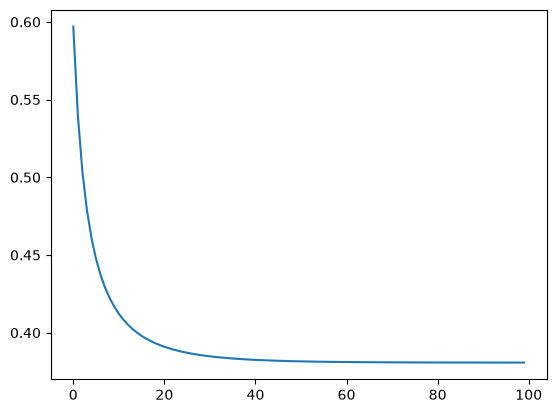

In [39]:
plt.plot(losses)

In [40]:
w

array([ 1.99281479, -1.82279131,  0.53004174])

In [41]:
wt

array([ 2. , -1. ,  0.5])

In [42]:
lambdareg = 0.1
def ridgeloss(X, y, w, lambdareg):
    return mseloss(X, y, w) + lambdareg * np.sum(w ** 2)

In [43]:
def ridgegrad(X, y, w, lambdareg):
    return msegrad(X, y, w) + 2 * lambdareg * w

In [50]:
np.random.seed(42)

In [51]:
n = 100
d = 3
wt = np.array([2.0, -1.0, 0.5])
X = np.random.randn(n, d)
noise = np.random.randn(n) * 0.1
y = X @ wt + noise
w = np.zeros(d) 

In [52]:
ridgegrad(X, y, w, lambdareg)

array([-2.73046502,  2.34518547, -1.09316721])

In [53]:
ridgeloss(X, y, w, lambdareg)

np.float64(4.177974370566786)

In [61]:
eta = 0.1
losses = []
for i in range(10000):
    grad = ridgegrad(X, y, w, lambdareg)
    w = w - eta * grad
    losses.append(ridgeloss(X, y, w, lambdareg))

w

array([ 1.73755042, -0.93369115,  0.44135727])

In [55]:
wt

array([ 2. , -1. ,  0.5])

In [66]:
wc = np.linalg.inv(X.T @ X + n * lambdareg * np.eye(d)) @ X.T @ y

In [67]:
print(wc)

[ 1.73755042 -0.93369115  0.44135727]


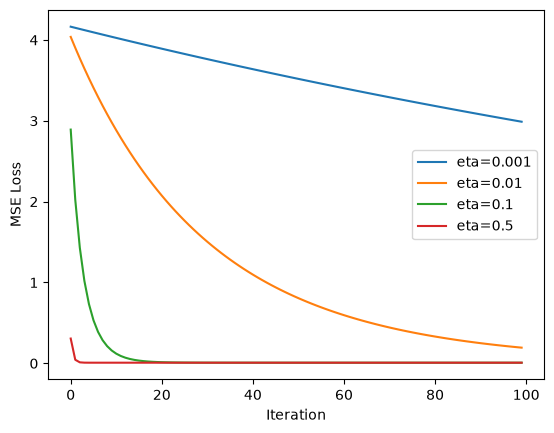

In [71]:
etas = [0.001, 0.01, 0.1, 0.5]
al = []

for i in range(4):
    w = np.zeros(d)
    l = []
    for j in range(100):
        grad = msegrad(X, y, w)
        w = w - etas[i] * grad
        l.append(mseloss(X, y, w))
    al.append(l)

for eta, losses in zip(etas, al):
    plt.plot(losses, label=f'eta={eta}')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.show()